In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, 
                             roc_auc_score, roc_curve,
                             confusion_matrix)
import xgboost as xgb
import shap

df = pd.read_csv('D:/Projects/Data Analytics/saas-churn-survival-analysis/data/processed/churn_clean.csv')
print(df.shape)
print(df['event'].value_counts())

(7043, 26)
event
0    5174
1    1869
Name: count, dtype: int64


In [5]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 
            'support_tickets', 'SeniorCitizen',
            'Contract', 'InternetService',
            'TechSupport', 'OnlineSecurity', 'signup_channel']

df_model = df[features + ['event']].copy()

# Encode categorical columns
for col in ['SeniorCitizen', 'Contract', 'InternetService',
            'TechSupport', 'OnlineSecurity', 'signup_channel']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Split into train and test
X = df_model.drop('event', axis=1)
y = df_model['event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")

Training set: (5634, 10)
Test set: (1409, 10)
Churn rate in test: 26.5%


In [6]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.940

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      1035
           1       0.70      0.87      0.77       374

    accuracy                           0.87      1409
   macro avg       0.82      0.87      0.84      1409
weighted avg       0.88      0.87      0.87      1409



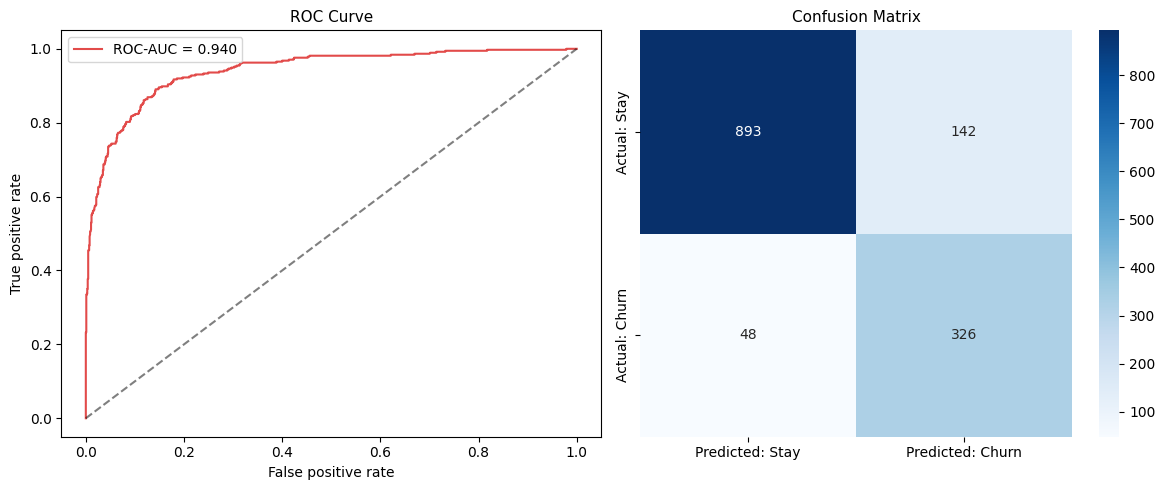

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#E24B4A', 
             label=f'ROC-AUC = 0.940')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve', fontsize=11)
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[1],
            xticklabels=['Predicted: Stay','Predicted: Churn'],
            yticklabels=['Actual: Stay','Actual: Churn'])
axes[1].set_title('Confusion Matrix', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

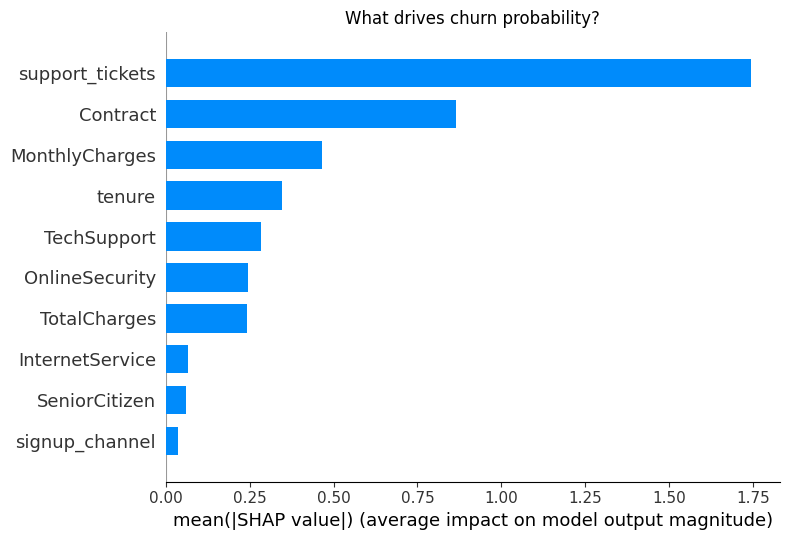

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, 
                  plot_type='bar', show=False)
plt.title('What drives churn probability?')
plt.tight_layout()
plt.savefig('../outputs/charts/shap_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Add churn probability and risk tier to full dataset
df['churn_prob'] = model.predict_proba(
    df_model.drop('event', axis=1))[:, 1]

df['risk_tier'] = pd.cut(df['churn_prob'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High'])

print(df['risk_tier'].value_counts())
print(f"\nAvg churn prob by tier:")
print(df.groupby('risk_tier')['churn_prob'].mean().round(3))

df.to_csv('../outputs/tableau_data/churn_scored.csv', index=False)
print("\nSaved to tableau_data folder")

risk_tier
Low       4449
High      1767
Medium     827
Name: count, dtype: int64

Avg churn prob by tier:
risk_tier
Low       0.097
Medium    0.552
High      0.912
Name: churn_prob, dtype: float32

Saved to tableau_data folder


C:\Users\jagra\AppData\Local\Temp\ipykernel_34800\1169848498.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('risk_tier')['churn_prob'].mean().round(3))


In [1]:
import pandas as pd

shap_data = pd.DataFrame({
    'feature': ['support_tickets', 'Contract', 'MonthlyCharges', 
                'tenure', 'TechSupport', 'OnlineSecurity',
                'TotalCharges', 'InternetService', 
                'SeniorCitizen', 'signup_channel'],
    'importance': [1.75, 0.85, 0.45, 0.32, 0.28, 
                   0.26, 0.25, 0.09, 0.07, 0.03]
})

shap_data.to_csv('../outputs/tableau_data/shap_importance.csv', index=False)
print("Saved")

Saved
